## Imports

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller

## Extract and Process the Dataset

In [17]:
df = pd.read_csv('Unemployment in America Per US State.csv')
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31747 entries, 0 to 31746
Data columns (total 11 columns):
 #   Column                                                     Non-Null Count  Dtype 
---  ------                                                     --------------  ----- 
 0   FIPS Code                                                  31747 non-null  int64 
 1   State/Area                                                 31747 non-null  object
 2   Year                                                       31747 non-null  int64 
 3   Month                                                      31747 non-null  int64 
 4   Total Civilian Non-Institutional Population in State/Area  31747 non-null  object
 5   Total Civilian Labor Force in State/Area                   31747 non-null  object
 6   Percent (%) of State/Area's Population                     31747 non-null  object
 7   Total Employment in State/Area                             31747 non-null  object
 8   Percent (%) of L

In [19]:
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7,1976-01-01
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3,1976-01-01
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2,1976-01-01


In [20]:

df['Total Unemployment in State/Area'] = pd.to_numeric(
    df['Total Unemployment in State/Area']
    .str.replace(",", "", regex=False),
    errors='coerce'
)

df['Total Civilian Labor Force in State/Area'] = pd.to_numeric(
    df['Total Civilian Labor Force in State/Area']
    .str.replace(",", "", regex=False),
    errors='coerce'
)

df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000",1486509.0,57.1,"1,387,606",53.3,98903.0,6.7,1976-01-01
1,2,Alaska,1976,1,"232,000",160709.0,69.3,"149,226",64.3,11483.0,7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000",963980.0,59.5,"865,261",53.4,98719.0,10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000",889912.0,57.9,"825,233",53.7,64679.0,7.3,1976-01-01
4,6,California,1976,1,"15,621,000",9770553.0,62.5,"8,873,133",56.8,897420.0,9.2,1976-01-01


In [ ]:
series = (
    df.groupby('date')
    .agg({
        'Total Unemployment in State/Area': 'sum',
        'Total Civilian Labor Force in State/Area': 'sum'
    })
)
 
series['unemployment_rate'] = (
    series['Total Unemployment in State/Area'] /
    series['Total Civilian Labor Force in State/Area']
) * 100

series = series.drop(columns=['Total Unemployment in State/Area', 'Total Civilian Labor Force in State/Area'])
series.dropna()

series.head()

,unemployment_rate
date,
1976-01-01,7.941620
1976-02-01,7.941561
1976-03-01,7.916780
1976-04-01,7.849169
1976-05-01,7.779528


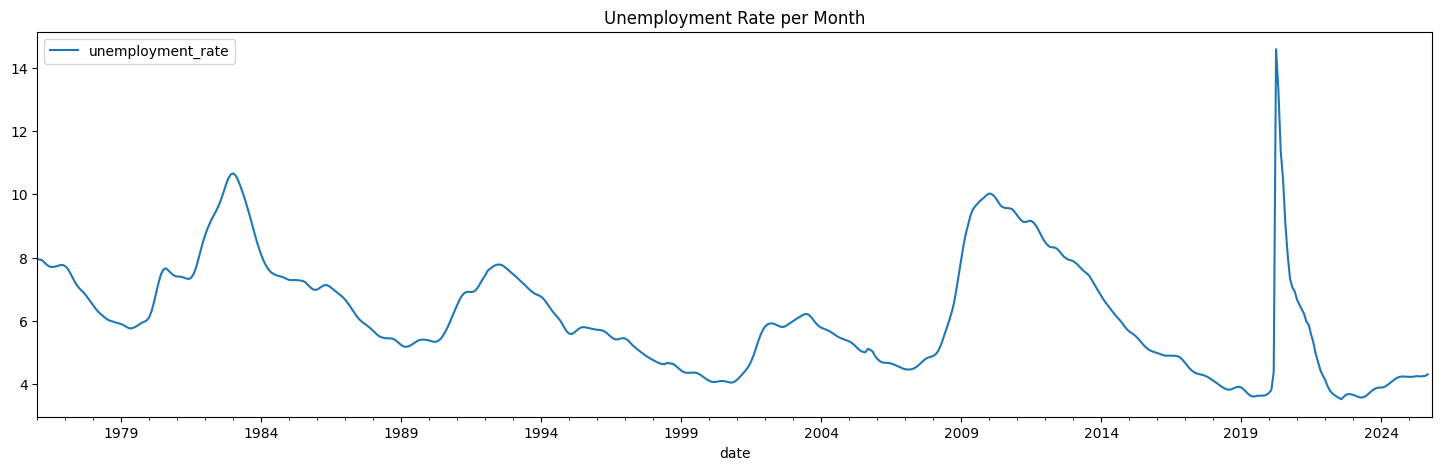

In [42]:
series.plot(figsize=(18, 5))
plt.title('Unemployment Rate per Month')
plt.show()

## Slipt the Series

In [ ]:
train = series[:-1]
test = series[-1:]

print(train.size)
print(test.size)

unemployment_rate    1
dtype: int64
598


## Check Stationarity

<Figure size 800x400 with 0 Axes>

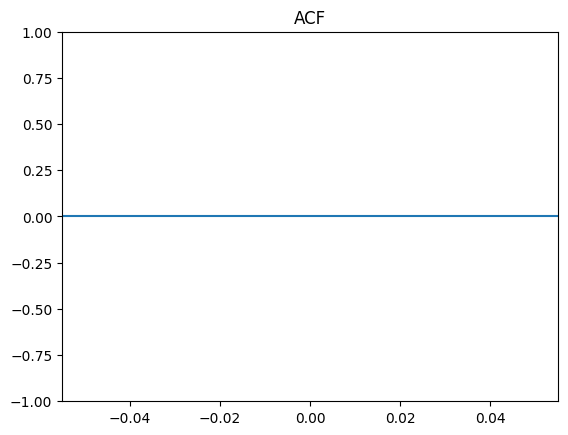

ValueError: cannot convert float NaN to integer

In [36]:
plt.figure(figsize=(8,4))
plot_acf(train, lags=30)
plt.title('ACF')
plt.show()

kpss_p = kpss(train)
adf_p = adfuller(train)

print(f'kpss: {kpss_p[1]}')
print(f'adf: {adf_p[1]}')
print(f'values: {adf_p[4]}')

In [47]:
series =series.dropna()

full_dates = pd.date_range(
    start=series.index.min(),
    end=series.index.max(),
    freq='MS'
)

missing_dates = full_dates.difference(series.index)

print(missing_dates)

DatetimeIndex(['2025-10-01'], dtype='datetime64[ns]', freq='MS')


,unemployment_rate
date,
2025-11-01,4.386602
